# Método de iteración de punto fijo

Para la realización de este código utilizaremos algunas definiciones y teoremas que se enuncian a continuación

1) Definición: Un punto fijo de una función $g$ es un número $p$ para el cual

    $g(p)=p$

    Dado un problema de buscar la raíz de p de la ecuación $f(p)=0$ podemos planter la función 
$g(p)=p-f(p)$

2) Teorema: Si $g \in C[a,b]$ y $g(x) \in C[a,b] \quad \forall x \in [a,b]$, entonces $g$ tiene un punto fijo en $[a,b]$ y si además $g'(x)$ existe en $(a,b)$ y existe una constante positiva $k<1$ con $|g'(x)|\leq k \quad \forall x \in (a,b)$ entonces el punto fijo en $[a,b]$ es único.

3) Teorema de punto fijo: Sea $g \in C[a,b]$ tal que $g(x) \in [a,b] \quad \forall x \in [a,b]$. Además supongamos que existen $g' \in (a,b)$ y una constante $k<1$ con $|g'(x)|\leq k \quad \forall x \in (a,b)$. Entonces para cualquier número $p_0 \in [a,b]$, la sucesión definida por

    $P_n=g(P_{n-1}), \quad n \geq 1$  

    converge en el único punto fijo $p$ en $[a,b]$


## Ejercicio
Muestre que $f(x)=x^3 + 4x^2 - 10 = 0$ tiene una raíz en $[1,2]$ y utilice el método de iteración de un punto fijo para determinar una aproximación a la raíz que sea precisa por lo menos dentro de $10^{-4}$

### Solución

Primero definamos la tolerancia, asignémosle una variable en el código y grafiquemos la función

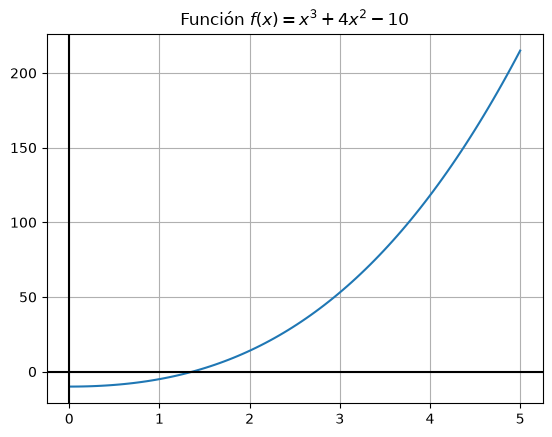

In [46]:
from IPython.display import display, Math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

def f(x):
    return pow(x,3) + 4*pow(x,2) - 10
tol=.0001
xx=np.linspace(0,5,100)
F1=f(xx)
plt.plot(xx,F1)
plt.title("Función $f(x) = x^3 + 4x^2 - 10 $")
plt.grid(True)
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.show()


Gráficamente concluimos que en efecto existe una raíz en ese intervalo, no obstante comprobemoslo analíticamente a través del teorema del valor intermedio

In [47]:
print(f"f(1)={f(1)}")
print(f"f(2)={f(2)}")

f(1)=-5
f(2)=14


Como $f \in C[1,2]$ y $0$ es un número entre $f(1)$ y $f(2)$, existe un número $c$ en $(1,2)$ para el cual $f(c)=0$, es decir, la raíz del polinomio existe.

Ahora exhibamos algunas posibles combinaciones para nuestro g(x), sabiendo que g(x)=x:

a) $g_1(x) = x - (x^3 + 4x^2 - 10)$

b) $g_2(x) = 10/(x^2 + 4x) $

c) $g_3(x) = \sqrt{\frac{10-x^3}{4}}$

d) $g_4(x)= \sqrt[3]{10-4x^2}$

e) $g_5(x) = \sqrt{\frac{10}{x+4}}$

Ahora definamos un máximo de iteraciones, un punto inicial, descartemos las funciones que no convergen y veamos cuantas iteraciones necesita cada una de las funciones que podrían converger

In [48]:
while True:
    try:
        p=float(input("Ingrese un punto incial: "))
        if p>=1 and p<=2:
            break
        else:
            print("Ingrese un número dentro del intervalo")
    except:
        pass
while True:
    try:
        max_it=int(input("Ingrese el número máximo de iteraciones: "))
        break
    except:
        print("Ingrese un número válido")
def g_1(x):
    return x - (pow(x,3) + 4*pow(x,2) -10)
def g_2(x):
    return 10/(pow(x,2) + 4*x)
def g_3(x):
    return np.sqrt(10 - pow(x,3))
def g_4(x):
    return np.cbrt(10 - 4*pow(x,2))
def g_5(x): 
    return np.sqrt(10/(x+4))

funciones=[]
g_j=[g_1,g_2,g_3,g_4,g_5]
for j in range(5):
    if g_j[j](1)<1 or g_j[j](1)>2 or g_j[j](2)<1 or g_j[j](2)>2:
        print(f"g_{j+1} no converge")
    else:
        print(f"g_{j+1} podría converger")
        funciones.append(g_j[j])
for t in range(len(funciones)):
    print("")
    print("-----------------------------")
    print(f"Evaluando {funciones[t].__name__}")
    print("-----------------------------")
    i=0
    p_=[p]
    print(f"{'# iter':<8}{'P_n':<12}{'g(p)':<12}{'error':<12}")
    while i<=max_it:
        g_p=funciones[t](p_[i])
        if funciones[t](1)<1 or funciones[t](1)>2 or funciones[t](2)<1 or funciones[t](2)>2 :
            print(f"{funciones[t]} no converge")
            break
        elif np.abs(g_p-p_[i]) <= tol:
            print(f"p={g_p}")
            break
        else:
            p_.append(g_p)
            print(f"{i:<8}{p_[i]:<12.7f}{g_p:<12.7f}{np.abs(g_p - p_[i]):<12.7f}")
            i+=1

Ingrese un punto incial:  1
Ingrese el número máximo de iteraciones:  100


g_1 no converge
g_2 no converge
g_3 no converge
g_4 no converge
g_5 podría converger

-----------------------------
Evaluando g_5
-----------------------------
# iter  P_n         g(p)        error       
0       1.0000000   1.4142136   0.4142136   
1       1.4142136   1.3590402   0.0551733   
2       1.3590402   1.3660182   0.0069780   
3       1.3660182   1.3651297   0.0008885   
4       1.3651297   1.3652428   0.0001130   
p=1.3652283902601083


El programa determinó una raíz aproximada resolviendo el ejercicio propuesto, no obstante, no hemos demostrado analíticamente que $g_5$ converge, solo sabemos que podría converger.

Determinemos la derivada de $g_5$ y comprobemos si cumple las condiciones del teorema 3

In [52]:
sp.init_printing()
x=sp.Symbol('x')
f=sp.sqrt(10/(x+4))
df=sp.diff(f,x)
df_simplificada=sp.simplify(df)
display(Math(f"g'(x)={sp.latex(df_simplificada)}"))

<IPython.core.display.Math object>

En efecto $g' \in (1,2)$, además para este intervalo la función siempre es negativa, es decir, la función es monótona decreciente. Ahora evaluemos su valor absoluto en los extremos $[1,2]$ para determinar si se cumple que $|g'(x)| < 1 \quad \forall x \in (1,2)$

In [59]:
g_prima=sp.lambdify(x,df_simplificada)
print(f"|g'(1)|={np.abs(g_prima(1))}")
print(f"|g'(2)|={np.abs(g_prima(2))}")

|g'(1)|=0.1414213562373095
|g'(2)|=0.1075828707279838


Concluimos que para $\sqrt{\frac{10}{x+4}}$

$P_n=g(P_{n-1}), \quad n \geq 1$ converge en un único punto fijo $p$ en $[1,2]$ 

donde la aproximación del punto con una precisión de $10^{-4}$ es p=1.3652283902601083